# Public Library Outlets (FY2022) — Data Analysis
**Dataset:** IMLS Public Libraries Survey, FY2022 – *Outlet* file (`pls_fy22_outlet_pud22i.csv`) · 17,546 outlets × 39 attributes
**Guiding question:** *where is public-library access (measured by opening hours) weakest, and why?*

| Phase | Content |
|---|---|
| 1 | Attribute types · data quality · missing-data handling · Min-Max normalization |
| 2 | Central tendency (ungrouped & grouped) · dispersion · skewness · IQR outliers |
| 3 | Histograms · boxplots · scatter plots & pair-plots · scoreboard + interactive dashboard |
| 4 | Insights · real-world context · actionable recommendations |

### Executive summary
| # | Finding | Evidence |
|---|---|---|
| 1 | **Rural outlets are the under-served group.** | 19.0% of rural outlets are open < 1,000 h/yr vs 3.0–4.8% elsewhere; rural outlets are 37% of the sample but 74% of under-served ones |
| 2 | **The gap is largely a building-size gap.** | Rural median floor area ≈ 2,800 sq ft vs ≈ 13,000 in cities; hours and size are strongly related (Spearman ≈ 0.70) |
| 3 | **Shortage is geographically concentrated.** | Alaska, Maine, South Dakota, Kansas, Wyoming and Vermont have 24–44% under-served outlets vs a ≈ 9% state median |
| 4 | **Data quality needed fixing first.** |

In [ ]:
import os, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 60, "display.width", 200, "display.float_format", "{:,.3f}".format)
RNG = np.random.default_rng(42)

FILE = "pls_fy22_outlet_pud22i.csv"
CANDIDATES = [os.path.join("/mnt/user-data/uploads", FILE), FILE, os.path.join("data", FILE)]
DATA_PATH = next((p for p in CANDIDATES if os.path.exists(p)), FILE)   # <- edit if your file lives elsewhere
print("Reading:", DATA_PATH)

Reading: pls_fy22_outlet_pud22i.csv


# Phase 1 — Dataset Understanding & Data Preprocessing
## 1.1 Load the data

In [ ]:
def load(path):
    for enc in ("utf-8", "latin1"):
        try:
            return pd.read_csv(path, encoding=enc, dtype={"LOCALE": str, "ZIP4": str}, low_memory=False)
        except UnicodeDecodeError:
            continue
raw = load(DATA_PATH)
print(f"Rows: {raw.shape[0]:,}   Columns: {raw.shape[1]}")
raw.head()

Rows: 17,546   Columns: 39


,STABR,FSCSKEY,FSCS_SEQ,C_FSCS,LIBID,LIBNAME,ADDRESS,CITY,ZIP,ZIP4,CNTY,PHONE,C_OUT_TY,SQ_FEET,F_SQ_FT,L_NUM_BM,HOURS,F_HOURS,WKS_OPEN,F_WKSOPN,YR_SUB,OBEREG,STATSTRU,STATNAME,STATADDR,LONGITUD,LATITUDE,CNTYPOP,LOCALE,CENTRACT,CENBLOCK,CDCODE,CBSA,MICROF,GEOSTATUS,GEOSCORE,GEOMTYPE,C19WKSCL,C19WKSLO
0,AK,AK0001,2,Y,AK0001-002,ANCHOR POINT PUBLIC LIBRARY,34020 NORTH FORK ROAD,ANCHOR POINT,99556,9150,KENAI PENINSULA,9072355692,CE,2880,R_22,0,1404,R_22,52,R_22,2023,8,0,0,0,-151.832,59.780,60690,43,2122000800,21220008003027,200,-4,N,E,100.000,POINTADDRESS,0,0
1,AK,AK0002,7,Y,AK0002-007,CHUGIAK-EAGLE RIVER LIBRARY,12001 BUSINESS BOULEVARD #176,EAGLE RIVER,99577,7743,ANCHORAGE,9073431530,BR,25452,R_22,0,1510,R_22,38,R_22,2023,8,0,0,0,-149.571,61.330,287145,31,2020000201,20200002012000,200,11260,0,E,100.000,SUBADDRESS,10,0
2,AK,AK0002,8,Y,AK0002-008,MULDOON LIBRARY,"1251 MULDOON ROAD, SUITE 158",ANCHORAGE,99504,2012,ANCHORAGE,9073434223,BR,8204,R_22,0,1500,R_22,38,R_22,2023,8,0,0,0,-149.733,61.211,287145,11,2020000703,20200007035009,200,11260,0,E,100.000,SUBADDRESS,10,0
3,AK,AK0002,10,Y,AK0002-010,SCOTT AND WESLEY GERRISH LIBRARY,250 EGLOFF DRIVE,GIRDWOOD,99587,M,ANCHORAGE,9073434024,BR,3938,R_22,0,1525,R_22,38,R_22,2023,8,0,0,0,-149.135,60.960,287145,42,2020002900,20200029002090,200,11260,0,E,100.000,POINTADDRESS,10,0
4,AK,AK0002,11,Y,AK0002-011,Z. J. LOUSSAC LIBRARY,3600 DENALI STREET,ANCHORAGE,99503,6093,ANCHORAGE,9073432892,CE,146171,R_22,0,1544,R_22,38,R_22,2023,8,0,0,0,-149.876,61.187,287145,11,2020001900,20200019004016,200,11260,0,E,100.000,POINTADDRESS,10,0


## 1.2 Attribute identification
Every column is classified by **scale** (Nominal / Ordinal / Interval / Ratio) and **nature** (Discrete / Continuous), and mapped to the operations that make sense for it.
Numeric-looking identifiers (ZIP, PHONE, CENTRACT…) are **Nominal** – averaging them would be meaningless.

In [ ]:
N, O, I, R = "Nominal", "Ordinal", "Interval", "Ratio"
ops = {N: "mode, counts, frequency tables", O: "mode, median, percentiles, rank correlation",
       I: "mean, SD, differences (no true zero → no ratios)", R: "all arithmetic, ratios, geometric mean"}
attr = {  # column: (description, scale, discrete/continuous)
 "STABR":("State/territory abbreviation",N,"Discrete"), "FSCSKEY":("Library-system ID",N,"Discrete"),
 "FSCS_SEQ":("Outlet sequence no. within system",N,"Discrete"), "C_FSCS":("Counted in FSCS (Y/N)",N,"Discrete"),
 "LIBID":("Outlet ID",N,"Discrete"), "LIBNAME":("Outlet name",N,"Discrete"), "ADDRESS":("Street address",N,"Discrete"),
 "CITY":("City",N,"Discrete"), "ZIP":("ZIP code (ID)",N,"Discrete"), "ZIP4":("ZIP+4 extension",N,"Discrete"),
 "CNTY":("County name",N,"Discrete"), "PHONE":("Phone number (ID)",N,"Discrete"),
 "C_OUT_TY":("Outlet type: CE central, BR branch, BS bookmobile, BM books-by-mail",N,"Discrete"),
 "SQ_FEET":("Floor area (sq ft)",R,"Continuous"), "F_SQ_FT":("Data flag for SQ_FEET",N,"Discrete"),
 "L_NUM_BM":("No. of bookmobiles",R,"Discrete"), "HOURS":("Total annual public service hours",R,"Continuous"),
 "F_HOURS":("Data flag for HOURS",N,"Discrete"), "WKS_OPEN":("Weeks open in year",R,"Discrete"), "F_WKSOPN":("Data flag for WKS_OPEN",N,"Discrete"),
 "YR_SUB":("Submission year (constant)",I,"Discrete"), "OBEREG":("BEA region code",N,"Discrete"),
 "STATSTRU":("Status-change code: structure",N,"Discrete"), "STATNAME":("Status-change code: name",N,"Discrete"), "STATADDR":("Status-change code: address",N,"Discrete"),
 "LONGITUD":("Longitude",I,"Continuous"), "LATITUDE":("Latitude",I,"Continuous"), "CNTYPOP":("County population served",R,"Discrete"),
 "LOCALE":("NCES locale (1x city, 2x suburb, 3x town, 4x rural; 2nd digit = size/proximity)",O,"Discrete"),
 "CENTRACT":("Census tract (ID)",N,"Discrete"), "CENBLOCK":("Census block (ID)",N,"Discrete"), "CDCODE":("Congressional district",N,"Discrete"),
 "CBSA":("Core-based statistical area code",N,"Discrete"), "MICROF":("Metro/micro flag",N,"Discrete"), "GEOSTATUS":("Geocode status",N,"Discrete"),
 "GEOSCORE":("Geocode match score (0-100)",R,"Continuous"), "GEOMTYPE":("Geocode match type",N,"Discrete"),
 "C19WKSCL":("COVID-19: weeks closed",R,"Discrete"), "C19WKSLO":("COVID-19: weeks with reduced hours",R,"Discrete"),
}
attr_df = pd.DataFrame(attr, index=["Description", "Scale", "Nature"]).T
attr_df["Suitable operations"] = attr_df["Scale"].map(ops)
attr_df["# unique"] = raw.nunique()
print(attr_df["Scale"].value_counts().to_string())
attr_df

Scale
Nominal     27
Ratio        8
Interval     3
Ordinal      1


,Description,Scale,Nature,Suitable operations,# unique
STABR,State/territory abbreviation,Nominal,Discrete,"mode, counts, frequency tables",56
FSCSKEY,Library-system ID,Nominal,Discrete,"mode, counts, frequency tables",9248
FSCS_SEQ,Outlet sequence no. within system,Nominal,Discrete,"mode, counts, frequency tables",165
C_FSCS,Counted in FSCS (Y/N),Nominal,Discrete,"mode, counts, frequency tables",2
LIBID,Outlet ID,Nominal,Discrete,"mode, counts, frequency tables",14110
LIBNAME,Outlet name,Nominal,Discrete,"mode, counts, frequency tables",16002
ADDRESS,Street address,Nominal,Discrete,"mode, counts, frequency tables",16605
CITY,City,Nominal,Discrete,"mode, counts, frequency tables",9143
ZIP,ZIP code (ID),Nominal,Discrete,"mode, counts, frequency tables",15394
ZIP4,ZIP+4 extension,Nominal,Discrete,"mode, counts, frequency tables",5630


> ### Interpretation
* Most of the 39 columns are **Nominal** (IDs, names, codes, flags). Only a handful are true measurements: `SQ_FEET`, `HOURS`, `WKS_OPEN`, `CNTYPOP`, the COVID counts (**Ratio** – they have a real zero) and latitude/longitude (**Interval** – zero is arbitrary, so ratios are meaningless).
* `LOCALE` is **Ordinal**: the first digit (city → suburb → town → rural) is a ranking, but the gaps between ranks are not equal.
* **Why it matters:** this decides which statistics are legitimate – means and SDs for ratio variables, modes and counts for nominal ones, medians / rank methods for ordinal ones.

## 1.3 Data-quality assessment
We check for **(a)** true missing values, **(b)** hidden missing codes, **(c)** duplicate rows, **(d)** noisy / impossible values and **(e)** data-entry inconsistencies.
The survey uses negative numbers (−1 not reported, −3 closed/suspended, −4 not applicable) instead of blanks.

In [ ]:
# (a) true NaNs
nulls = raw.isna().sum(); print("True NaNs:\n", nulls[nulls > 0].to_string())

# (b) negative sentinel codes hidden inside numeric columns
num_cols = ["SQ_FEET", "HOURS", "WKS_OPEN", "L_NUM_BM", "C19WKSCL", "C19WKSLO"]
sent = pd.DataFrame({c: {"-1 (not reported)": (raw[c] == -1).sum(), "-3 (closed/suspended)": (raw[c] == -3).sum(),
                         "-4 (not applicable)": (raw[c] == -4).sum(), "0": (raw[c] == 0).sum()} for c in num_cols}).T
display(sent)
print("Which outlet types carry the negative SQ_FEET codes?")
display(pd.crosstab(raw["C_OUT_TY"], raw["SQ_FEET"].where(raw["SQ_FEET"] < 0), margins=True))

# (c) duplicates
dup = {"Fully duplicated rows": raw.duplicated().sum(),
       "Duplicated (FSCSKEY, FSCS_SEQ)": raw.duplicated(["FSCSKEY", "FSCS_SEQ"]).sum(),
       "Duplicated LIBID (non-null)": raw.LIBID.dropna().duplicated().sum(),
       "Duplicated (LIBNAME, ADDRESS, CITY)": raw.duplicated(["LIBNAME", "ADDRESS", "CITY"]).sum()}
print("\nDuplicates:"); print(pd.Series(dup).to_string())

True NaNs:
 LIBID    2


,-1 (not reported),-3 (closed/suspended),-4 (not applicable),0
SQ_FEET,164,96,639,0
HOURS,602,96,0,93
WKS_OPEN,513,96,0,166
L_NUM_BM,0,96,0,16813
C19WKSCL,1368,96,0,14779
C19WKSLO,1323,96,0,14626


Which outlet types carry the negative SQ_FEET codes?


SQ_FEET,-4.000,-3.000,-1.000,All
C_OUT_TY,,,,
BM,2,0,0,2
BR,0,59,48,107
BS,637,24,0,661
CE,0,13,116,129
All,639,96,164,899



Duplicates:
Fully duplicated rows                     0
Duplicated (FSCSKEY, FSCS_SEQ)            0
Duplicated LIBID (non-null)            3434
Duplicated (LIBNAME, ADDRESS, CITY)      88


In [ ]:
# (d) + (e) noise and inconsistencies - rule-based audit
h, w, s = raw.HOURS, raw.WKS_OPEN, raw.SQ_FEET
rules = {
 "HOURS > 168 x WKS_OPEN  (physically impossible)": (h > 168 * w) & (h >= 0) & (w >= 0),
 "HOURS == 8,760  (24 h x 365 d placeholder)":      (h == 8760),
 "WKS_OPEN > 52":                                   (w > 52),
 "HOURS > 0 but WKS_OPEN == 0":                     (h > 0) & (w == 0),
 "SQ_FEET > 200,000 (extreme size)":                (s > 200_000),
 "COVID weeks closed/reduced > 52":                 (raw.C19WKSCL > 52) | (raw.C19WKSLO > 52),
 "ZIP lost its leading zero (< 5 digits)":          (raw.ZIP < 10000),
 "ZIP4 shorter than 4 digits":                      (raw.ZIP4.str.len() < 4),
 "LIBNAME has leading/trailing whitespace":         (raw.LIBNAME != raw.LIBNAME.str.strip()),
 "LIBNAME contains a back-tick":                    raw.LIBNAME.str.contains("`", regex=False),
 "LOCALE = 'M' (non-numeric code)":                 (raw.LOCALE == "M"),
}
audit = pd.Series({k: int(v.sum()) for k, v in rules.items()}, name="rows affected").to_frame()
audit["% of rows"] = 100 * audit["rows affected"] / len(raw)
audit

,rows affected,% of rows
HOURS > 168 x WKS_OPEN (physically impossible),148,0.843
"HOURS == 8,760 (24 h x 365 d placeholder)",1,0.006
WKS_OPEN > 52,7,0.040
HOURS > 0 but WKS_OPEN == 0,77,0.439
"SQ_FEET > 200,000 (extreme size)",43,0.245
COVID weeks closed/reduced > 52,3,0.017
ZIP lost its leading zero (< 5 digits),2024,11.535
ZIP4 shorter than 4 digits,2821,16.078
LIBNAME has leading/trailing whitespace,0,0.000
LIBNAME contains a back-tick,36,0.205


> ### Interpretation
* **The biggest hazard was hidden, not missing.** Only 2 true `NaN`s exist (both `LIBID`), but the numeric columns hide negative codes: `SQ_FEET` has 899 (−1: 164, −3: 96, −4: 639) and `HOURS` has 698 (−1: 602, −3: 96). Left as numbers they would drag means down and inflate spreads.
* **The codes mean different things.** The 96 `-3` outlets are temporarily closed in every field. `-4` appears **only** on bookmobiles / books-by-mail – they have no building, so this is *structural* missingness, not a gap to fill.
* **Noise:** 148 outlets (0.84%) report more hours than a calendar allows (> 168 h × weeks open), including a 24 × 365 = 8,760 placeholder.
* **Inconsistencies:** ≈ 11.5% of ZIP codes lost a leading zero (New England style), 36 names contain a back-tick, 13 locales are the letter `M`.
* **Duplicates:** no repeated rows and `(FSCSKEY, FSCS_SEQ)` is a valid unique key. `LIBID` is **not** unique, so it must not be used to de-duplicate. Shared name + address + city records are mostly a central library and its bookmobile – legitimate.

## 1.4 Cleaning & missing-data handling
**Strategy**
1. Convert sentinels → `NaN`. Closed outlets (`-3`) are **excluded** – nothing to impute, they were not operating.
2. `-4` on `SQ_FEET` is *structural* (bookmobile / mail) → stays `NaN`; floor-area statistics use **buildings** only.
3. Impossible hours → `NaN` (noise treated as missing).
4. Impute the rest: `WKS_OPEN` → **mode**; `SQ_FEET` → **group median** (outlet type × locale, robust to skew); `HOURS` → the best of **mean / median / interpolation / regression** in a masked-validation test.

In [ ]:
df = raw.copy()
# --- text / identifier repairs
df["LIBNAME"] = df.LIBNAME.str.strip().str.replace("`", "'", regex=False)
df["ZIP"]  = df.ZIP.astype(str).str.zfill(5)
df["ZIP4"] = df.ZIP4.astype(str).str.zfill(4)
df["LIBID"] = df.LIBID.fillna(df.FSCSKEY + "-" + df.FSCS_SEQ.astype(int).astype(str).str.zfill(3))

# --- sentinels -> NaN, closed outlets flagged
df["closed"] = (raw[["SQ_FEET", "HOURS", "WKS_OPEN"]] == -3).any(axis=1)
for c in ["SQ_FEET", "HOURS", "WKS_OPEN", "L_NUM_BM"]:
    df[c] = raw[c].where(raw[c] >= 0)
noisy = (raw.HOURS > 168 * raw.WKS_OPEN) & (raw.HOURS >= 0) & (raw.WKS_OPEN >= 0)
df.loc[noisy, "HOURS"] = np.nan                       # impossible -> missing
df["L_NUM_BM"] = df.L_NUM_BM.fillna(0)
for c in ["C19WKSCL", "C19WKSLO"]:                    # -1 or > 52 weeks -> NaN (left missing, not imputed)
    df[c] = raw[c].where(raw[c].between(0, 52))

# --- derived categorical helpers
loc_map = {"1": "City", "2": "Suburb", "3": "Town", "4": "Rural", "M": "Unknown"}
df["loc_group"] = pd.Categorical(df.LOCALE.str[0].map(loc_map), ["City", "Suburb", "Town", "Rural", "Unknown"], ordered=True)
df["outlet_type"] = df.C_OUT_TY.map({"CE": "Central", "BR": "Branch", "BS": "Bookmobile", "BM": "Books-by-mail"})

act = df[~df.closed].copy()                           # open outlets only
print("Closed/suspended outlets excluded:", int(df.closed.sum()), "| impossible HOURS set to NaN:", int(noisy.sum()))
miss = pd.DataFrame({"missing": act[["SQ_FEET", "HOURS", "WKS_OPEN"]].isna().sum(),
                     "% of open outlets": 100 * act[["SQ_FEET", "HOURS", "WKS_OPEN"]].isna().mean()})
display(miss)
display(pd.crosstab(act.outlet_type, act.SQ_FEET.isna().map({True: "SQ_FEET missing", False: "SQ_FEET present"})))

Closed/suspended outlets excluded: 96 | impossible HOURS set to NaN: 148


,missing,% of open outlets
SQ_FEET,803,4.602
HOURS,750,4.298
WKS_OPEN,513,2.940


SQ_FEET,SQ_FEET missing,SQ_FEET present
outlet_type,,
Bookmobile,637,0
Books-by-mail,2,0
Branch,48,7704
Central,116,8943


In [ ]:
# ---- Step A: WKS_OPEN -> mode
wk_mode = act.WKS_OPEN.mode()[0]; print("WKS_OPEN mode =", wk_mode)
act["WKS_OPEN"] = act.WKS_OPEN.fillna(wk_mode)

# ---- Step B: SQ_FEET (buildings only) -> median by outlet type x locale group
bld_mask = act.C_OUT_TY.isin(["CE", "BR"])
act["sqft_imputed"] = act.SQ_FEET.isna() & bld_mask
grp_med = act[bld_mask].groupby(["C_OUT_TY", "loc_group"], observed=True).SQ_FEET.transform("median")
act.loc[bld_mask, "SQ_FEET"] = act.loc[bld_mask, "SQ_FEET"].fillna(grp_med).fillna(act.loc[bld_mask, "SQ_FEET"].median())

# ---- Step C: HOURS -> compare imputers by hiding 15% of the known values
def design(d):
    X = pd.DataFrame({"WKS_OPEN": d.WKS_OPEN, "log_sqft": np.log1p(d.SQ_FEET.fillna(0)),
                      "log_pop": np.log10(d.CNTYPOP)}, index=d.index)
    X = X.join(pd.get_dummies(d.C_OUT_TY, prefix="t", drop_first=True, dtype=float))
    return X.join(pd.get_dummies(d.loc_group.astype(str), prefix="l", drop_first=True, dtype=float))
X_all = design(act)
obs = act.HOURS.notna()
idx_obs = act.index[obs]
test_idx = RNG.choice(idx_obs, size=int(.15 * len(idx_obs)), replace=False)
train_idx = idx_obs.difference(test_idx)
y_h = act.HOURS

def m_mean(tr, te):   return pd.Series(y_h[tr].mean(), index=te)
def m_median(tr, te): return pd.Series(y_h[tr].median(), index=te)
def m_interp(tr, te):                                  # linear interpolation along ascending floor-area order
    order = act.assign(k=np.log1p(act.SQ_FEET.fillna(0))).loc[tr.union(te)].sort_values("k")
    s = y_h.loc[order.index].copy(); s.loc[te] = np.nan
    return s.interpolate(limit_direction="both").loc[te]
def m_reg(tr, te):
    lr = LinearRegression().fit(X_all.loc[tr], y_h[tr])
    return pd.Series(lr.predict(X_all.loc[te]), index=te).clip(lower=0)

res = {}
for name, fn in {"Mean": m_mean, "Median": m_median, "Linear interpolation": m_interp, "Linear regression": m_reg}.items():
    p = fn(train_idx, pd.Index(test_idx)); t = y_h[test_idx]
    res[name] = {"RMSE": np.sqrt(((p - t) ** 2).mean()), "MAE": (p - t).abs().mean()}
res = pd.DataFrame(res).T.sort_values("RMSE"); display(res)
print("Best imputer for HOURS:", res.index[0])

WKS_OPEN mode = 52.0


,RMSE,MAE
Linear regression,512.257,401.643
Linear interpolation,691.578,530.329
Mean,787.978,629.420
Median,791.945,626.040


Best imputer for HOURS: Linear regression


Regression R² (in-sample) = 0.594


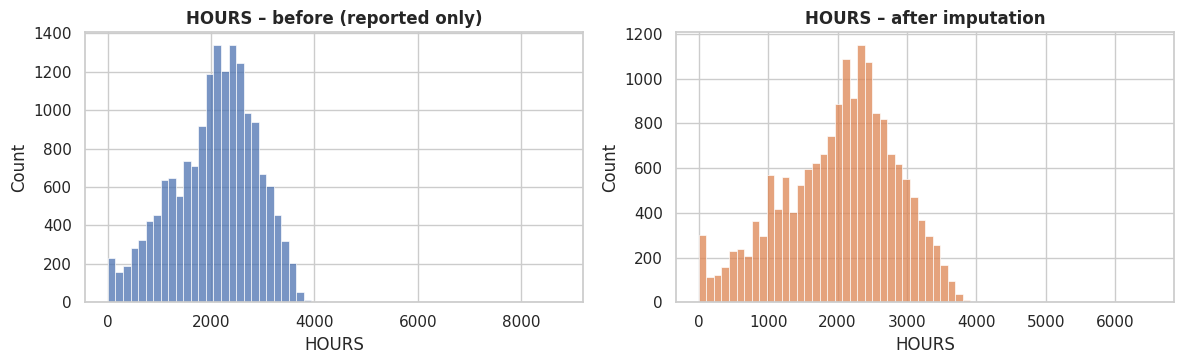

Remaining NaN - HOURS: 0, WKS_OPEN: 0 | open outlets: 17,450 | buildings: 16,811


In [ ]:
# apply regression to the real gaps, respecting the physical limit (168 h x weeks open)
act["hours_imputed"] = act.HOURS.isna()
lr = LinearRegression().fit(X_all[obs], act.HOURS[obs])
print(f"Regression R² (in-sample) = {lr.score(X_all[obs], act.HOURS[obs]):.3f}")
pred = pd.Series(lr.predict(X_all[~obs]), index=act.index[~obs])
act.loc[~obs, "HOURS"] = np.minimum(pred.clip(lower=0), 168 * act.loc[~obs, "WKS_OPEN"])
act["HOURS"] = act.HOURS.round()

before = raw.loc[act.index, "HOURS"].where(lambda s: s >= 0)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
sns.histplot(before.dropna(), bins=60, ax=ax[0], color="C0"); ax[0].set_title("HOURS – before (reported only)")
sns.histplot(act.HOURS, bins=60, ax=ax[1], color="C1");        ax[1].set_title("HOURS – after imputation")
plt.tight_layout(); plt.show()

# analysis frames
ana = act.copy()                                       # all open outlets
ana["hours_per_week"] = (ana.HOURS / ana.WKS_OPEN.replace(0, np.nan)).clip(upper=168)
bld = ana[ana.C_OUT_TY.isin(["CE", "BR"])].copy()      # buildings (for floor-area analysis)
print(f"Remaining NaN - HOURS: {ana.HOURS.isna().sum()}, WKS_OPEN: {ana.WKS_OPEN.isna().sum()} | open outlets: {len(ana):,} | buildings: {len(bld):,}")

> ### Interpretation
* **Less to impute than it first appears.** Of 803 missing `SQ_FEET` among open outlets, 639 are bookmobiles (structural) – only **164 buildings (≈ 1%)** are real gaps. Hours: 750 missing (4.3%, including the 148 noisy values); weeks open: 513 (2.9%).
* **Method comparison (15% of known hours hidden, then predicted):** regression RMSE ≈ **512 h** vs interpolation ≈ 694 h, mean ≈ 788 h and median ≈ 792 h. Regression wins because hours are partly predictable from size, locale, weeks open and outlet type.
* **Why interpolation lost:** neighbours in floor-area order can have very different schedules.
* **Caution:** imputed values sit near the conditional mean, so they *understate variability*. For that reason the Phase 4 evidence uses **reported** values only.

## 1.5 Data transformation & normalization — Min-Max
Features live on very different scales (hours ≈ 10³, floor area ≈ 10⁴, county population ≈ 10⁶). **Min-Max normalization** rescales each to [0, 1]:

$$x' = \frac{x - x_{min}}{x_{max} - x_{min}}$$

In [ ]:
def minmax(x): return (x - x.min()) / (x.max() - x.min())

bld["log_sqft"]    = np.log10(bld.SQ_FEET.clip(lower=1))     # helper columns used later
bld["log_cntypop"] = np.log10(bld.CNTYPOP)

cols = ["SQ_FEET", "HOURS", "WKS_OPEN", "CNTYPOP"]
norm = bld[cols].copy()
for c in cols:
    norm[c + "_minmax"] = minmax(bld[c])
norm["log_sqft_minmax"] = minmax(bld.log_sqft)               # same idea on the log scale
display(norm.head(6))
display(norm.filter(like="_minmax").describe().loc[["min", "50%", "max", "mean"]].T)

,SQ_FEET,HOURS,WKS_OPEN,CNTYPOP,SQ_FEET_minmax,HOURS_minmax,WKS_OPEN_minmax,CNTYPOP_minmax,log_sqft_minmax
0,"2,880.000","1,404.000",52.000,60690,0.003,0.215,0.981,0.006,0.440
1,"25,452.000","1,510.000",38.000,287145,0.026,0.231,0.717,0.030,0.649
2,"8,204.000","1,500.000",38.000,287145,0.008,0.230,0.717,0.030,0.540
3,"3,938.000","1,525.000",38.000,287145,0.004,0.234,0.717,0.030,0.470
4,"146,171.000","1,544.000",38.000,287145,0.151,0.237,0.717,0.030,0.818
5,"10,704.000","1,517.000",38.000,287145,0.011,0.233,0.717,0.030,0.566


,min,50%,max,mean
SQ_FEET_minmax,0.000,0.007,1.000,0.013
HOURS_minmax,0.000,0.331,1.000,0.319
WKS_OPEN_minmax,0.000,0.981,1.000,0.945
CNTYPOP_minmax,0.000,0.013,1.000,0.063
log_sqft_minmax,0.000,0.524,1.000,0.519


> ### Interpretation
* Min-Max puts every feature on [0, 1] so no variable dominates just because of its units – essential before comparing or combining features.
* **But it is sensitive to the extreme value.** With a 970,000 sq-ft maximum (Boston), ordinary libraries map to only ≈ 0.003–0.03 on the floor-area scale, while `HOURS` (no extreme tail) spreads sensibly (≈ 0.2 for the median).
* **Min-Max of the log-area** (last column) spreads buildings across the interval – so for skewed variables, *transform first, then normalize*.

# Phase 2 — Exploratory & Statistical Data Analysis
## 2.1 Measures of central tendency
Arithmetic mean, weighted mean, geometric mean, median and mode – first on **ungrouped** (raw) data.
Weights: floor area by opening hours · hours by weeks open · weeks open and county population by opening hours (busier outlets count more).

In [ ]:
VARS = {"SQ_FEET (buildings)": bld.SQ_FEET, "HOURS (open outlets)": ana.HOURS, "WKS_OPEN": ana.WKS_OPEN, "CNTYPOP": ana.CNTYPOP}
weights = {"SQ_FEET (buildings)": bld.HOURS, "HOURS (open outlets)": ana.WKS_OPEN,
           "WKS_OPEN": ana.HOURS.clip(lower=1), "CNTYPOP": ana.HOURS.clip(lower=1)}

def central(name, x):
    x = x.dropna(); pos = x[x > 0]
    return {"n": len(x), "Arithmetic mean": x.mean(), "Weighted mean": np.average(x, weights=weights[name].loc[x.index]),
            "Geometric mean (x>0)": stats.gmean(pos), "Median": x.median(), "Mode": x.mode().iloc[0]}
ct = pd.DataFrame({k: central(k, v) for k, v in VARS.items()}); display(ct)

,SQ_FEET (buildings),HOURS (open outlets),WKS_OPEN,CNTYPOP
n,"16,811.000","17,450.000","17,450.000","17,450.000"
Arithmetic mean,"12,912.562","2,036.251",49.667,"613,745.725"
Weighted mean,"16,118.859","2,092.107",51.029,"683,593.137"
Geometric mean (x>0),"6,575.664","1,822.426",49.067,"134,112.161"
Median,"6,910.000","2,115.000",52.000,"126,027.000"
Mode,"10,000.000","2,080.000",52.000,"9,721,138.000"


> ### Interpretation
* **Floor area:** mean ≈ 12,913 vs median ≈ 6,910 vs geometric mean ≈ 6,576. The mean is nearly **double** the median – a right-skewed variable where the mean describes no typical library; median / geometric mean are the honest summaries.
* **Weighted mean** of area (weighted by opening hours) ≈ 16,119 > arithmetic mean: bigger buildings are open longer – a first hint of the size–hours link.
* **Hours:** mean ≈ 2,036 ≈ median ≈ 2,115 – nearly symmetric. The modal value 2,080 = 40 h × 52 weeks, the classic full-time schedule.
* **Weeks open:** median and mode 52, mean ≈ 49.7 – most outlets are open all year; a minority with long closures pull the mean down.
* **County population:** mean ≈ 614k vs median ≈ 126k. The "mode" is an artefact: one very large county's value repeats for each of its outlets.

### Grouped data
For `HOURS` we build a frequency table (class width 500 h) and compute mean, median and mode **from the table**:
mean = Σf·m / n · median = L + ((n/2 − cf<sub>prev</sub>) / f) · h · mode (Czuber) = L + d₁/(d₁+d₂) · h

In [ ]:
def grouped_central(x, width, lo, hi):
    x = x.dropna(); edges = np.arange(lo, hi + width, width)
    f, _ = np.histogram(x, bins=edges)
    mid = (edges[:-1] + edges[1:]) / 2; n = f.sum(); cf = f.cumsum()
    mean = (f * mid).sum() / n
    sd = np.sqrt((f * (mid - mean) ** 2).sum() / (n - 1))
    m = np.searchsorted(cf, n / 2)                                       # median class
    median = edges[m] + ((n / 2 - (cf[m - 1] if m else 0)) / f[m]) * width
    k = f.argmax()                                                       # modal class
    d1 = f[k] - (f[k - 1] if k else 0); d2 = f[k] - (f[k + 1] if k + 1 < len(f) else 0)
    mode = edges[k] + d1 / (d1 + d2) * width
    tab = pd.DataFrame({"class": [f"{a:,.0f}–{b:,.0f}" for a, b in zip(edges[:-1], edges[1:])], "f": f, "midpoint": mid, "cum f": cf, "f·m": f * mid})
    return tab, dict(mean=mean, sd=sd, median=median, mode=mode, median_class=tab["class"][m], modal_class=tab["class"][k])

tab, g = grouped_central(ana.HOURS, 500, 0, 9000)
display(tab[tab.f > 0])
display(pd.DataFrame({"Grouped (width 500)": [g["mean"], g["median"], g["mode"], g["sd"]],
                      "Ungrouped (raw)": [ana.HOURS.mean(), ana.HOURS.median(), ana.HOURS.mode()[0], ana.HOURS.std()]},
                     index=["Mean", "Median", "Mode", "Std dev"]))
print("Median class:", g["median_class"], "| Modal class:", g["modal_class"])

,class,f,midpoint,cum f,f·m
0,0–500,800,250.000,800,"200,000.000"
1,"500–1,000",1312,750.000,2112,"984,000.000"
2,"1,000–1,500",2234,"1,250.000",4346,"2,792,500.000"
3,"1,500–2,000",3133,"1,750.000",7479,"5,482,750.000"
4,"2,000–2,500",4735,"2,250.000",12214,"10,653,750.000"
5,"2,500–3,000",3248,"2,750.000",15462,"8,932,000.000"
6,"3,000–3,500",1694,"3,250.000",17156,"5,505,500.000"
7,"3,500–4,000",272,"3,750.000",17428,"1,020,000.000"
8,"4,000–4,500",10,"4,250.000",17438,"42,500.000"
9,"4,500–5,000",7,"4,750.000",17445,"33,250.000"


,Grouped (width 500),Ungrouped (raw)
Mean,"2,044.384","2,036.251"
Median,"2,131.573","2,115.000"
Mode,"2,259.307","2,080.000"
Std dev,818.602,820.341


Median class: 2,000–2,500 | Modal class: 2,000–2,500


> ### Interpretation
* Grouping reproduces the raw statistics closely: **mean ≈ 2,044 vs 2,036, median ≈ 2,132 vs 2,115, SD ≈ 819 vs 820**.
* The **mode is the least stable** (≈ 2,259 grouped vs 2,080 raw) because it depends on class width and position; the raw mode is the 40 h × 52 wk schedule.
* Median class = modal class = **2,000–2,500 h**, holding ≈ 27% of outlets.
* **Takeaway:** grouped formulas are reliable for mean / median / SD when classes are narrow and data fairly symmetric (handy when only a published frequency table exists), but not for the mode.

## 2.2 Measures of dispersion
Range, variance, standard deviation, root-mean-square (RMS) deviation and the **coefficient of dispersion** (Q3 − Q1)/(Q3 + Q1), a unit-free spread measure that lets us compare variables.

In [ ]:
def dispersion(x):
    x = x.dropna(); q1, q3 = x.quantile([.25, .75]); mu = x.mean()
    return {"Range": x.max() - x.min(), "Variance (sample)": x.var(ddof=1), "Std dev (sample)": x.std(ddof=1),
            "RMS deviation (about mean)": np.sqrt(((x - mu) ** 2).mean()),
            "Coeff. of dispersion (Q3−Q1)/(Q3+Q1)": (q3 - q1) / (q3 + q1)}
disp = pd.DataFrame({k: dispersion(v) for k, v in VARS.items()}); display(disp)

,SQ_FEET (buildings),HOURS (open outlets),WKS_OPEN,CNTYPOP
Range,"969,970.000","6,524.000",53.000,"9,720,905.000"
Variance (sample),"662,634,904.021","672,960.116",66.416,"1,941,050,842,146.782"
Std dev (sample),"25,741.696",820.341,8.150,"1,393,216.007"
RMS deviation (about mean),"25,740.930",820.318,8.149,"1,393,176.086"
Coeff. of dispersion (Q3−Q1)/(Q3+Q1),0.668,0.271,0.000,0.892


> ### Interpretation
* Absolute spreads are in different units, so compare the **coefficient of dispersion**: county population ≈ 0.89 > floor area ≈ 0.67 > hours ≈ 0.27 > weeks open = 0.
* **Floor area:** SD ≈ 25,742 is about twice the mean and the range is ≈ 969,970 sq ft, yet the middle half of libraries is tightly packed (IQR ≈ 12,015). The extremes are enormous, the typical library is not.
* **Hours** are comparatively consistent (SD ≈ 820): most outlets run roughly 1,500–2,600 h.
* **Weeks open:** coefficient = 0 because ≥ 75% of outlets are open exactly 52 weeks; all variation comes from a minority with part-year closures.
* The RMS deviation about the mean equals the (population) SD – a useful consistency check.

## 2.3 Shape measures & outlier analysis
**Skewness:** Pearson's 1st (mean − mode)/σ, Pearson's 2nd 3(mean − median)/σ and **Bowley's** (Q3 + Q1 − 2·Q2)/(Q3 − Q1).
**Outliers:** the **IQR rule** – anything outside [Q1 − 1.5·IQR, Q3 + 1.5·IQR] is flagged (beyond 3·IQR = extreme).

In [ ]:
def shape(x):
    x = x.dropna(); q1, q2, q3 = x.quantile([.25, .5, .75]); mu, sd = x.mean(), x.std(ddof=1)
    cnt, edges = np.histogram(x, bins="auto"); mode_est = (edges[cnt.argmax()] + edges[cnt.argmax() + 1]) / 2
    return {"Pearson #1 (mean−mode)/σ": (mu - mode_est) / sd, "Pearson #2 3(mean−median)/σ": 3 * (mu - q2) / sd,
            "Bowley (Q3+Q1−2Q2)/(Q3−Q1)": (q3 + q1 - 2 * q2) / (q3 - q1) if q3 > q1 else np.nan}
display(pd.DataFrame({k: shape(v) for k, v in VARS.items()}))

def iqr_outliers(x):
    x = x.dropna(); q1, q3 = x.quantile([.25, .75]); i = q3 - q1
    lo, hi = q1 - 1.5 * i, q3 + 1.5 * i
    return {"Q1": q1, "Q3": q3, "IQR": i, "Lower fence": lo, "Upper fence": hi,
            "# outliers": int(((x < lo) | (x > hi)).sum()), "% outliers": 100 * ((x < lo) | (x > hi)).mean(),
            "# extreme (3×IQR)": int(((x < q1 - 3 * i) | (x > q3 + 3 * i)).sum())}
orow = {k: iqr_outliers(v) for k, v in VARS.items()}
orow["log10 SQ_FEET"] = iqr_outliers(bld.log_sqft); orow["Hours per week"] = iqr_outliers(ana.hours_per_week)
display(pd.DataFrame(orow))
display(bld.nlargest(5, "SQ_FEET")[["LIBNAME", "CITY", "STABR", "SQ_FEET", "HOURS", "outlet_type"]].set_index("LIBNAME"))

,SQ_FEET (buildings),HOURS (open outlets),WKS_OPEN,CNTYPOP
Pearson #1 (mean−mode)/σ,0.446,-0.048,-0.206,0.425
Pearson #2 3(mean−median)/σ,0.700,-0.288,-0.859,1.050
Bowley (Q3+Q1−2Q2)/(Q3−Q1),0.347,-0.105,NaN,0.657


,SQ_FEET (buildings),HOURS (open outlets),WKS_OPEN,CNTYPOP,log10 SQ_FEET,Hours per week
Q1,"2,985.500","1,500.000",52.000,"32,843.000",3.475,30.613
Q3,"15,000.000","2,612.750",52.000,"575,980.750",4.176,51.577
IQR,"12,014.500","1,112.750",0.000,"543,137.750",0.701,20.963
Lower fence,"-15,036.250",-169.125,52.000,"-781,863.625",2.423,-0.832
Upper fence,"33,021.750","4,281.875",52.000,"1,390,687.375",5.228,83.022
# outliers,"1,221.000",14.000,"3,693.000","1,819.000",92.000,110.000
% outliers,7.263,0.080,21.163,10.424,0.547,0.636
# extreme (3×IQR),555.000,1.000,"3,693.000","1,142.000",0.000,69.000


,CITY,STABR,SQ_FEET,HOURS,outlet_type
LIBNAME,,,,,
BOSTON PUBLIC LIBRARY,BOSTON,MA,"970,000.000","3,672.000",Central
CHICAGO PUBLIC LIBRARY,CHICAGO,IL,"756,000.000","3,400.000",Central
STEPHEN A. SCHWARZMAN BUILDING,NEW YORK,NY,"660,000.000","2,864.000",Central
DALLAS PUBLIC LIBRARY,DALLAS,TX,"646,733.000","2,080.000",Central
"CINCINNATI AND HAMILTON COUNTY, PL OF",CINCINNATI,OH,"550,000.000","2,704.000",Central


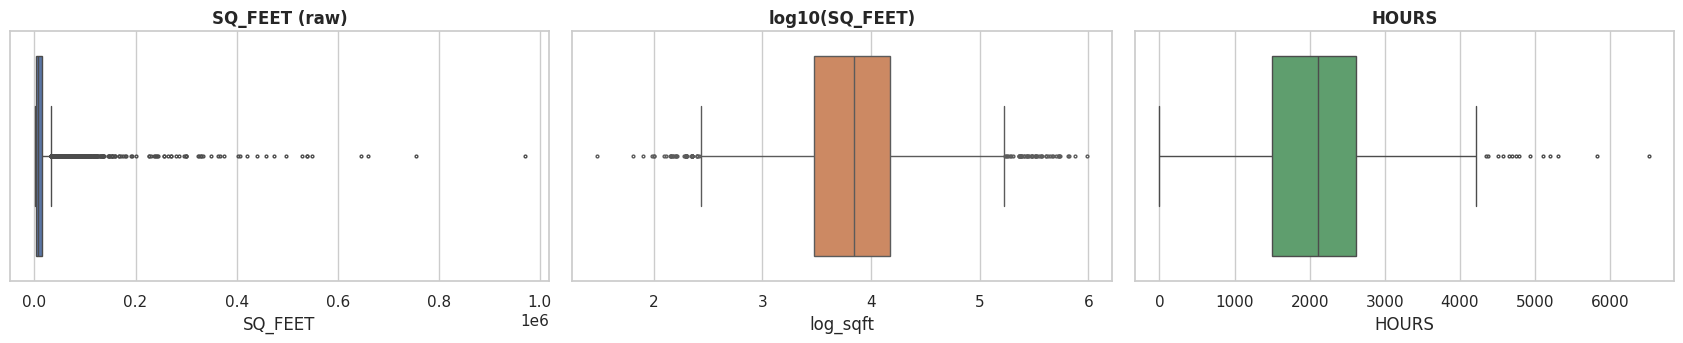

In [ ]:
# Boxplots: raw vs log scale (outliers are a scale artefact for skewed variables)
fig, ax = plt.subplots(1, 3, figsize=(17, 3.6))
sns.boxplot(x=bld.SQ_FEET, ax=ax[0], color="C0", fliersize=2);  ax[0].set_title("SQ_FEET (raw)")
sns.boxplot(x=bld.log_sqft, ax=ax[1], color="C1", fliersize=2);  ax[1].set_title("log10(SQ_FEET)")
sns.boxplot(x=ana.HOURS, ax=ax[2], color="C2", fliersize=2);     ax[2].set_title("HOURS")
plt.tight_layout(); plt.show()

> ### Interpretation
* **Floor area is strongly right-skewed:** Pearson #2 ≈ 0.70 and Bowley ≈ 0.35 (positive = long right tail), consistent with a mean that is nearly double the median. Hours are close to symmetric, with a mild left skew; weeks open has a spike at 52 and a long left tail (Bowley is undefined because IQR = 0).
* **Outliers in area are mostly a symptom of skew, not errors:** 1,221 buildings (7.3%) are flagged on the raw scale, but on the **log scale only 92 (0.5%)** and none extreme – the boxplot above shows this directly.
* The largest buildings are genuine landmarks (Boston Public Library 970,000 sq ft, Chicago 756,000, New York 660,000) – **keep them**.
* **Hours:** just 14 outliers (0.08%). **Hours per week:** 110 flagged, 69 extreme (above ≈ 114 h/week) – implausible for staffed libraries and worth verifying.
* **Weeks open:** the IQR rule flags every value ≠ 52 – it is **not applicable** to near-constant data.
* **Decision:** keep genuine giants, analyse area on a log scale, treat extreme weekly hours as suspect.

# Phase 3 — Visualization Selection & Graphical Representation
## 3.1 Frequency distributions — histograms
Histograms show the *shape* of one numeric variable. Dashed red = mean, dotted black = median.

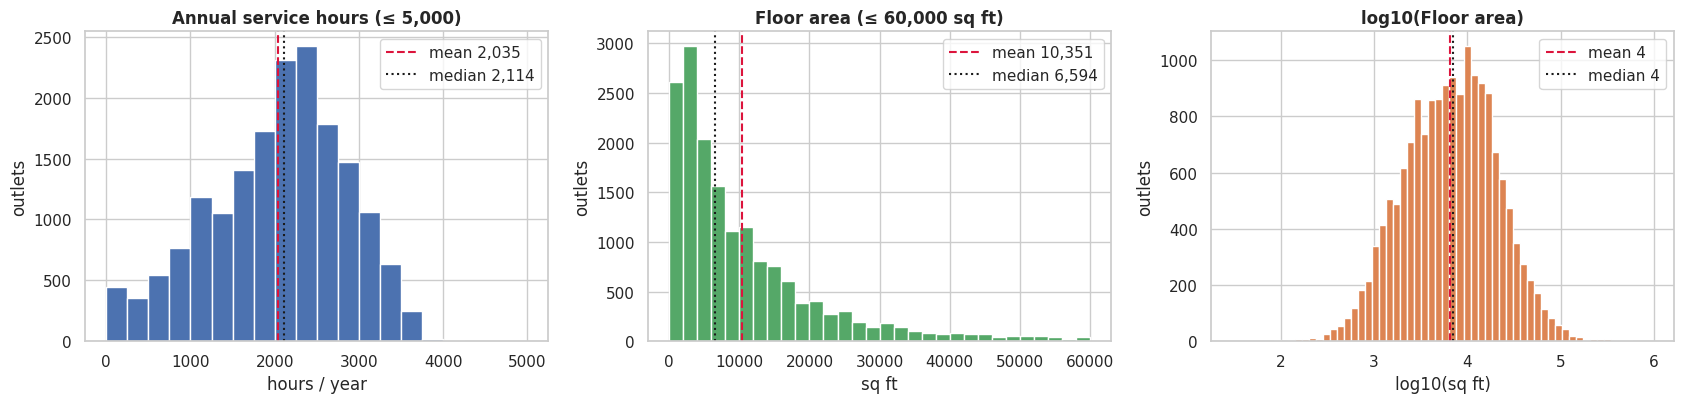

In [ ]:
def hist(ax, x, title, color, bins):
    ax.hist(x, bins=bins, color=color, edgecolor="white"); ax.set_title(title)
    ax.axvline(x.mean(), color="crimson", ls="--", label=f"mean {x.mean():,.0f}")
    ax.axvline(x.median(), color="k", ls=":", label=f"median {x.median():,.0f}"); ax.legend()
fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
hist(ax[0], ana.HOURS[ana.HOURS <= 5000], "Annual service hours (≤ 5,000)", "C0", np.arange(0, 5250, 250)); ax[0].set_xlabel("hours / year")
hist(ax[1], bld.SQ_FEET[bld.SQ_FEET <= 60000], "Floor area (≤ 60,000 sq ft)", "C2", np.arange(0, 62000, 2000)); ax[1].set_xlabel("sq ft")
hist(ax[2], bld.log_sqft, "log10(Floor area)", "C1", 60); ax[2].set_xlabel("log10(sq ft)")
for a in ax: a.set_ylabel("outlets")
plt.tight_layout(); plt.show()

> ### Interpretation
* **Hours:** a single hump, almost symmetric; quartiles ≈ **1,500 / 2,115 / 2,613 h**. Spikes at 2,080 (40 h × 52), 2,496 (48 h × 52) and 1,040 (20 h × 52) show hours follow **standard schedules**.
* **Floor area (raw):** sharp right skew – the mean sits right of the median, pulled by large buildings.
* **Floor area (log):** a smooth bell shape, i.e. floor area is roughly **log-normal** – which is why the log scale is used in later plots.
* **So what:** the shortage problem lives in the *lower tail of hours* (under ≈ 1,000 h) and the *small-size end* of area.

## 3.2 Boxplots — spread and outliers across groups

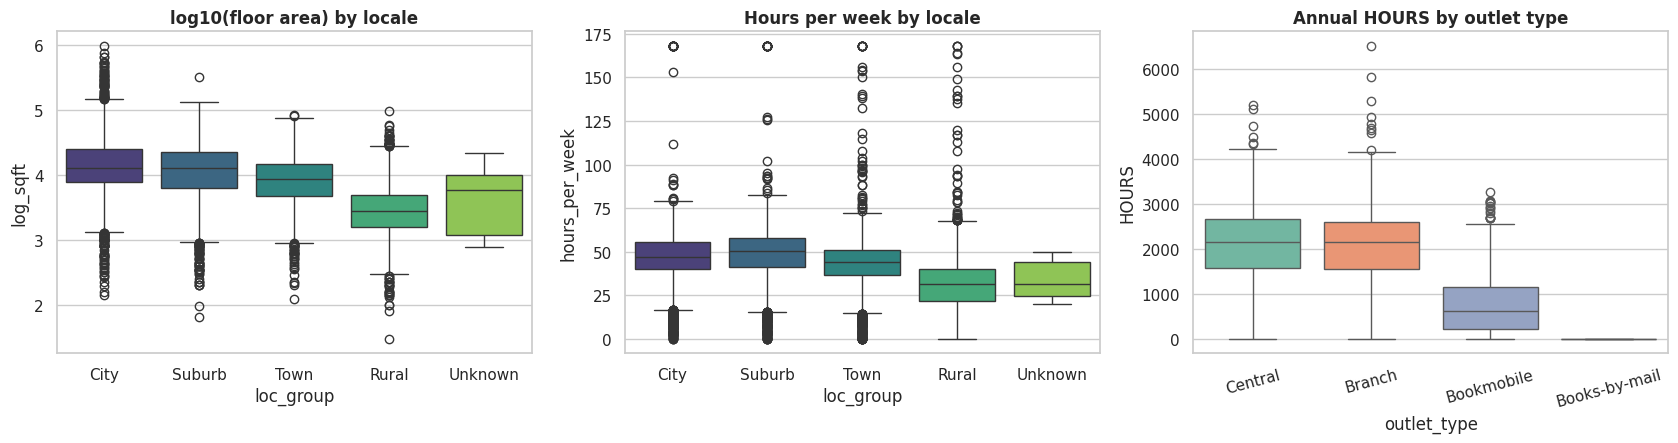

Median floor area by locale:
loc_group
City      13,000.000
Suburb    12,680.000
Town       8,712.000
Rural      2,812.000
Unknown    5,930.000

Median hours per week by locale:
loc_group
City      47.000
Suburb    50.500
Town      44.000
Rural     31.200
Unknown   31.500


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
sns.boxplot(data=bld, x="loc_group", y="log_sqft", ax=ax[0], palette="viridis");           ax[0].set_title("log10(floor area) by locale")
sns.boxplot(data=ana, x="loc_group", y="hours_per_week", ax=ax[1], palette="viridis");     ax[1].set_title("Hours per week by locale")
sns.boxplot(data=ana, x="outlet_type", y="HOURS", ax=ax[2], palette="Set2");               ax[2].set_title("Annual HOURS by outlet type")
ax[2].tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()
print("Median floor area by locale:"); print(bld.groupby("loc_group", observed=True).SQ_FEET.median().round(0).to_string())
print("\nMedian hours per week by locale:"); print(ana.groupby("loc_group", observed=True).hours_per_week.median().round(1).to_string())

> ### Interpretation
* **Locale gradient:** median floor area – City ≈ 13,000, Suburb ≈ 12,680, Town ≈ 8,712, **Rural ≈ 2,812** sq ft; median weekly hours – City 48, Suburb 51, Town 44.8, **Rural 31.5**. Rural boxes sit far below the others while city and suburb are close.
* **By outlet type:** central and branch libraries have a median ≈ 2,160 h, **bookmobiles ≈ 624 h**, books-by-mail 0 (no public hours) – so non-building outlets should be kept out of building-level comparisons.
* **Takeaway:** the urban–rural divide is visible in both size and hours; suburban outlets, not city ones, offer the longest hours.

## 3.3 Relational & bivariate plots — scatter plots, correlation, pair-plot

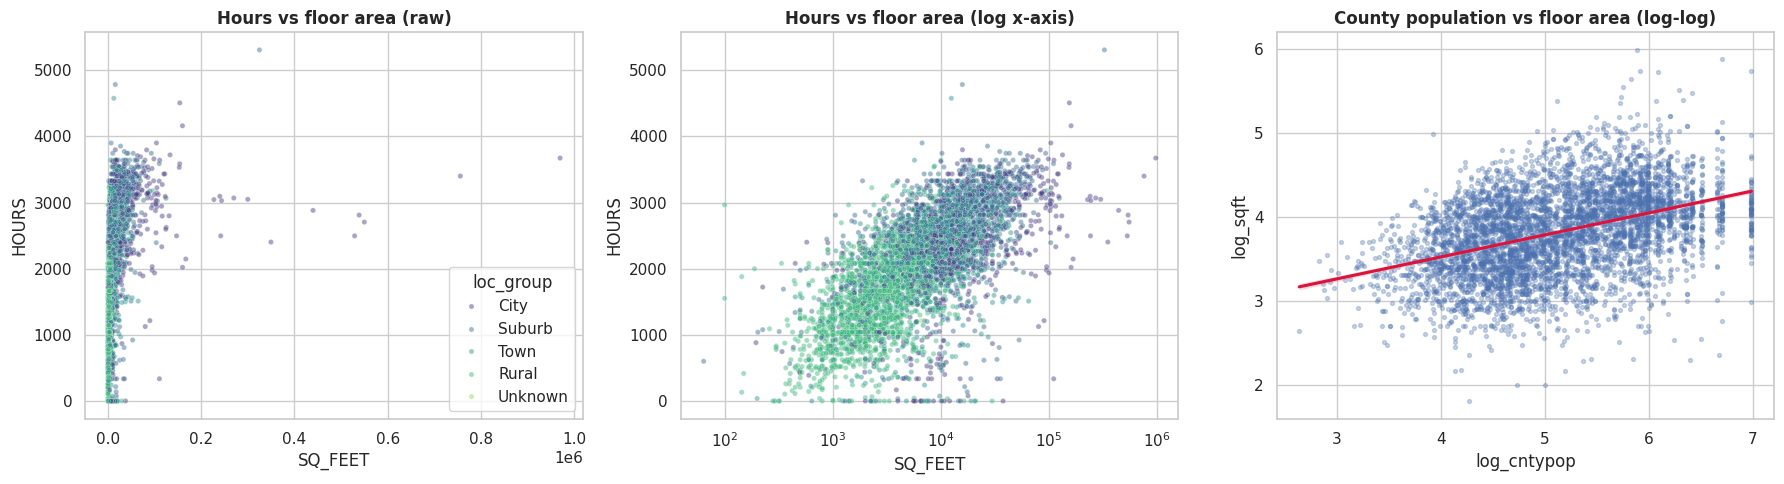

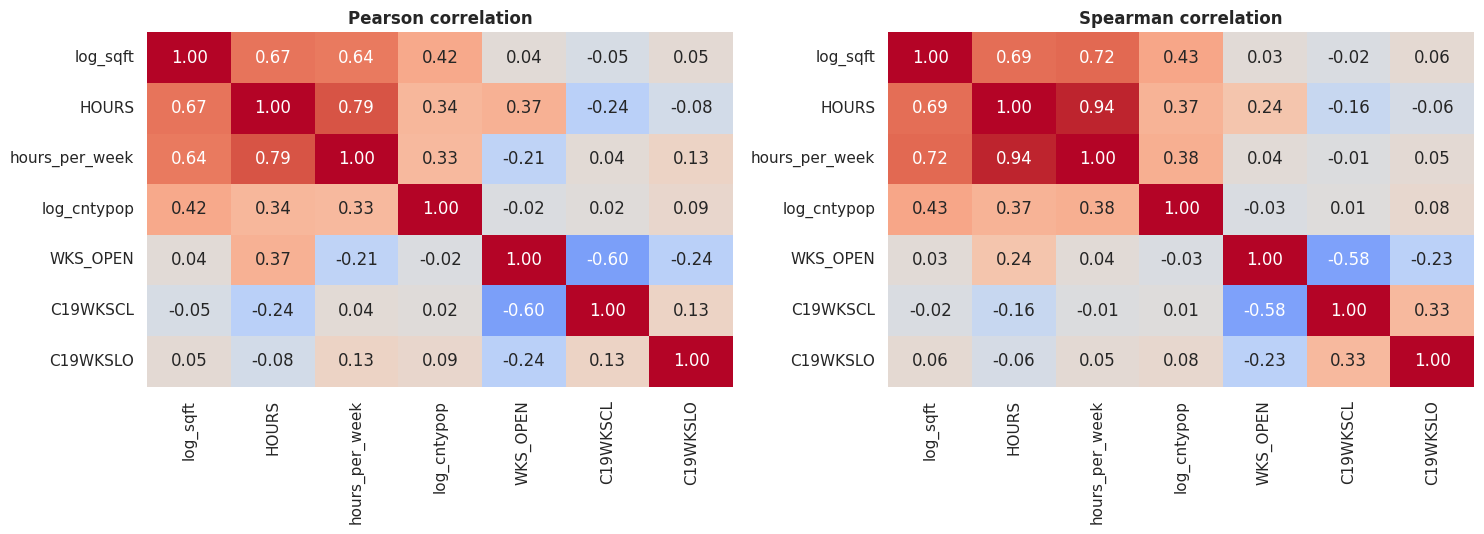

In [ ]:
smp = bld.sample(5000, random_state=0)
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=smp, x="SQ_FEET", y="HOURS", hue="loc_group", alpha=.45, s=14, ax=ax[0], palette="viridis"); ax[0].set_title("Hours vs floor area (raw)")
sns.scatterplot(data=smp, x="SQ_FEET", y="HOURS", hue="loc_group", alpha=.45, s=14, ax=ax[1], palette="viridis", legend=False)
ax[1].set_xscale("log"); ax[1].set_title("Hours vs floor area (log x-axis)")
sns.regplot(data=smp, x="log_cntypop", y="log_sqft", scatter_kws=dict(s=8, alpha=.3), line_kws=dict(color="crimson"), ax=ax[2])
ax[2].set_title("County population vs floor area (log-log)")
plt.tight_layout(); plt.show()

num = bld[["log_sqft", "HOURS", "hours_per_week", "log_cntypop", "WKS_OPEN", "C19WKSCL", "C19WKSLO"]]
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
for a, m in zip(ax, ["pearson", "spearman"]):
    sns.heatmap(num.corr(method=m), annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=a, cbar=False); a.set_title(f"{m.title()} correlation")
plt.tight_layout(); plt.show()

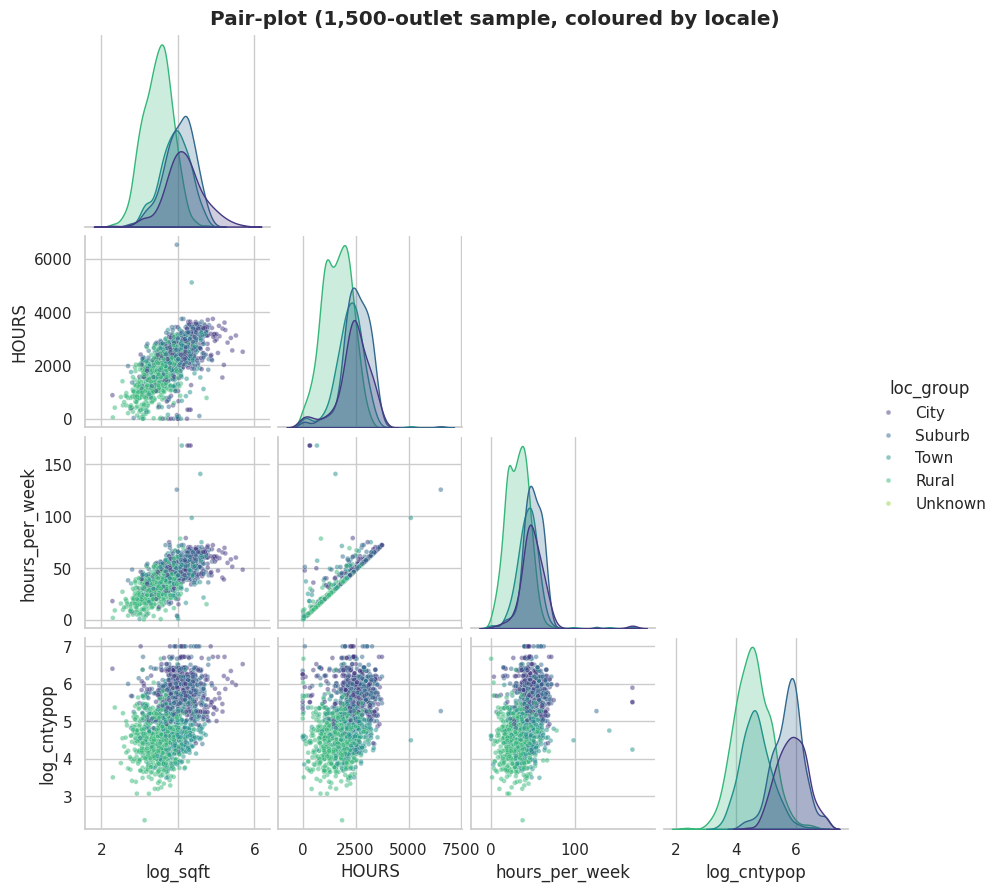

In [ ]:
pp = sns.pairplot(bld.sample(1500, random_state=1)[["log_sqft", "HOURS", "hours_per_week", "log_cntypop", "loc_group"]],
                  hue="loc_group", palette="viridis", corner=True, plot_kws=dict(s=12, alpha=.5), diag_kind="kde", height=2.2)
pp.fig.suptitle("Pair-plot (1,500-outlet sample, coloured by locale)", y=1.01, fontweight="bold"); plt.show()

> ### Interpretation
* **Size drives hours.** Hours vs log-area has Pearson / Spearman ≈ **0.67 / 0.69**; hours vs log-population is weaker (≈ 0.34 / 0.37); log-area vs log-population ≈ 0.42 / 0.43. Pearson and Spearman agree, so the relationships are monotone and not driven by outliers.
* **Population is partly borrowed from size:** counties with more people have bigger libraries, which in turn open longer – so population's apparent effect on hours is mostly indirect.
* **COVID:** weeks open vs COVID weeks closed ≈ −0.60, hours vs weeks closed ≈ −0.24, but weekly hours barely relate to closures (≈ 0.04) – closures removed *weeks*, not daily hours.
* **Pair-plot:** the same structure from every angle – a positive link between log-area and hours, rural outlets clustered at the small / low-hours end, city and suburb overlapping at the large end.
* **Caution:** correlation ≠ causation. Larger buildings and longer hours probably both reflect larger budgets and staffing, which the survey does not contain.

## 3.4 Scoreboard vs. dashboard
* **Scoreboard** – a handful of headline KPIs, readable at a glance.
* **Dashboard** – interactive drill-down: pick a *map metric* (left menu) and a *state* (right menu) to update the charts below.

In [ ]:
n_sys = ana.FSCSKEY.nunique(); n_st = ana.STABR.nunique()
kpis = [("Open outlets", len(ana), ",d"), ("Library systems", n_sys, ",d"), ("States/territories", n_st, "d"),
        ("Buildings", len(bld), ",d"), ("Bookmobiles / mail", int((~ana.C_OUT_TY.isin(["CE", "BR"])).sum()), ",d"),
        ("Median floor area (sq ft)", bld.SQ_FEET.median(), ",.0f"), ("Median hours / week", ana.hours_per_week.median(), ".1f"),
        ("% outlets in rural/town", 100 * ana.loc_group.isin(["Rural", "Town"]).mean(), ".1f")]
fig = make_subplots(rows=2, cols=4, specs=[[{"type": "indicator"}] * 4] * 2, vertical_spacing=.25)
for i, (t, v, fmt) in enumerate(kpis):
    fig.add_trace(go.Indicator(mode="number", value=v, title={"text": t, "font": {"size": 15}}, number={"valueformat": fmt, "font": {"size": 34}}), row=i // 4 + 1, col=i % 4 + 1)
fig.update_layout(height=300, margin=dict(t=40, b=10), title="Scoreboard – US public library outlets, FY2022", template="plotly_white")
fig.show()

In [ ]:
# ---------- state-level aggregates for the map
state_agg = ana.groupby("STABR").agg(outlets=("LIBID", "count"), median_hours_week=("hours_per_week", "median"),
                              pct_rural_town=("loc_group", lambda s: 100 * s.isin(["Rural", "Town"]).mean()),
                              covid_closed_wks=("C19WKSCL", "mean")).join(bld.groupby("STABR").SQ_FEET.median().rename("median_sqft")).reset_index()
metrics = {"Outlets (count)": "outlets", "Median hours / week": "median_hours_week", "Median floor area (sq ft)": "median_sqft",
           "% rural or town": "pct_rural_town", "Avg COVID weeks closed": "covid_closed_wks"}
first_col = next(iter(metrics.values()))
states = ["All states"] + sorted(ana.STABR.unique())
loc_order = ["City", "Suburb", "Town", "Rural"]

fig = make_subplots(rows=2, cols=2, row_heights=[.55, .45], vertical_spacing=.12,
                    specs=[[{"type": "choropleth", "colspan": 2}, None], [{"type": "xy"}, {"type": "xy"}]],
                    subplot_titles=("Choropleth by state (choose metric ▼)", "Outlets by locale (choose state ▼)", "Weekly opening hours (choose state ▼)"))
fig.add_trace(go.Choropleth(locations=state_agg.STABR, z=state_agg[first_col], locationmode="USA-states", colorscale="Viridis",
                            colorbar=dict(title="", len=.45, y=.78), hovertemplate="%{location}: %{z:,.1f}<extra></extra>"), row=1, col=1)
fig.update_geos(scope="usa", row=1, col=1)
for i, s in enumerate(states):
    d = ana if s == "All states" else ana[ana.STABR == s]
    cnt = d.loc_group.value_counts().reindex(loc_order, fill_value=0)
    fig.add_trace(go.Bar(x=loc_order, y=cnt.values, marker_color=["#440154", "#31688e", "#35b779", "#fde725"], visible=(i == 0), showlegend=False,
                         hovertemplate="%{x}: %{y:,}<extra></extra>"), row=2, col=1)
    fig.add_trace(go.Histogram(x=d.hours_per_week.dropna(), xbins=dict(start=0, end=84, size=3), marker_color="#31688e", visible=(i == 0), showlegend=False), row=2, col=2)
n_fixed = 1; n_state_traces = 2 * len(states)
state_buttons = []
for i, s in enumerate(states):
    vis = [False] * n_state_traces; vis[2 * i] = vis[2 * i + 1] = True
    state_buttons.append(dict(label=s, method="restyle", args=[{"visible": vis}, list(range(n_fixed, n_fixed + n_state_traces))]))
metric_buttons = [dict(label=lab, method="restyle", args=[{"z": [state_agg[col]]}, [0]]) for lab, col in metrics.items()]
fig.update_layout(height=780, template="plotly_white", title="Dashboard – drill down by metric and state", margin=dict(t=110),
    updatemenus=[dict(buttons=metric_buttons, x=0.0, y=1.14, xanchor="left", direction="down", showactive=True),
                 dict(buttons=state_buttons, x=0.55, y=1.14, xanchor="left", direction="down", showactive=True)])
fig.update_xaxes(title_text="Locale type", row=2, col=1); fig.update_xaxes(title_text="Hours per week", row=2, col=2)
fig.update_yaxes(title_text="Outlets", row=2, col=1);     fig.update_yaxes(title_text="Outlets", row=2, col=2)
fig.show()
display(state_agg.sort_values("outlets", ascending=False).head(10).set_index("STABR").round(1))

,outlets,median_hours_week,pct_rural_town,covid_closed_wks,median_sqft
STABR,,,,,
CA,1205,40.000,25.600,1.800,"8,756.000"
NY,1082,43.600,44.700,0.100,"7,500.000"
TX,884,42.000,50.500,0.400,"8,715.000"
IL,792,46.200,50.800,0.600,"8,550.000"
OH,769,49.000,51.800,0.100,"9,800.000"
MI,660,43.300,61.800,2.800,"6,328.000"
PA,632,42.500,35.100,0.200,"6,000.000"
IA,572,32.000,91.300,0.300,"3,252.000"
FL,555,48.000,24.700,0.100,"12,000.000"


> ### Interpretation
* **Scoreboard:** 17,450 open outlets in ≈ 9,238 library systems across 56 states/territories; 16,811 are buildings and 639 are bookmobile / mail outlets; the median building is ≈ 6,910 sq ft with ≈ 42 opening hours a week. A scoreboard answers *"how big / how much?"* but deliberately hides variation.
* **Dashboard:** the choropleth shows *where*, the locale bars show *what kind of places*, and the hours histogram shows *how long they open* – for any state you pick.
* **Largest states by outlets:** CA ≈ 1,205, NY ≈ 1,082, TX ≈ 884, IL ≈ 792, OH ≈ 769.
* **Weekly hours track rurality – with exceptions.** Iowa (91% rural/town) has a median of ≈ 32 h/week, the lowest; Ohio (≈ 49 h) and Florida (≈ 48 h) are highest. But Wisconsin (74% rural/town) still reaches ≈ 46 h and California (26% rural/town) is only ≈ 40 h – so **state funding and policy** probably matter beyond locale.

# Phase 4 — Data Interpretation
Phases 1–3 described the data. Here we turn it into a story: **what** the pattern is, **why** it exists, and **what to do about it**.

**Definition.** An outlet is **under-served** if it is open fewer than **1,000 hours a year** (≈ 20 h/week).
**Evidence sample:** buildings whose hours **and** floor area were genuinely *reported* (imputed values excluded), with a known locale.

In [ ]:
bl = bld[bld.loc_group != "Unknown"].copy(); bl["loc_group"] = bl.loc_group.cat.remove_unused_categories()
ob = bl[~bl.hours_imputed & ~bl.sqft_imputed].copy()
THR = 1000
ob["underserved"] = ob.HOURS < THR
print(f"Evidence sample: {len(ob):,} outlets | 1,000 h/yr is the {stats.percentileofscore(ob.HOURS, THR):.1f}th percentile of reported hours")
print(f"Under-served share: {ob.underserved.mean():.2%} (reported only) vs {(bl.HOURS < THR).mean():.2%} (including imputed rows)")

tab = ob.groupby("loc_group", observed=True).agg(n=("HOURS", "size"), under=("underserved", "sum"),
                                                  median_hours=("HOURS", "median"), median_sqft=("SQ_FEET", "median"))
tab["rate_%"] = 100 * tab.under / tab.n
tab["share of all under-served %"] = 100 * tab.under / tab.under.sum()
display(tab.round(1))

Evidence sample: 16,098 outlets | 1,000 h/yr is the 9.5th percentile of reported hours
Under-served share: 9.40% (reported only) vs 9.94% (including imputed rows)


,n,under,median_hours,median_sqft,rate_%,share of all under-served %
loc_group,,,,,,
City,2742,131,"2,432.000","13,096.000",4.800,8.700
Suburb,4253,129,"2,600.000","13,000.000",3.000,8.500
Town,3215,133,"2,288.000","8,700.000",4.100,8.800
Rural,5888,1121,"1,604.000","2,841.000",19.000,74.000


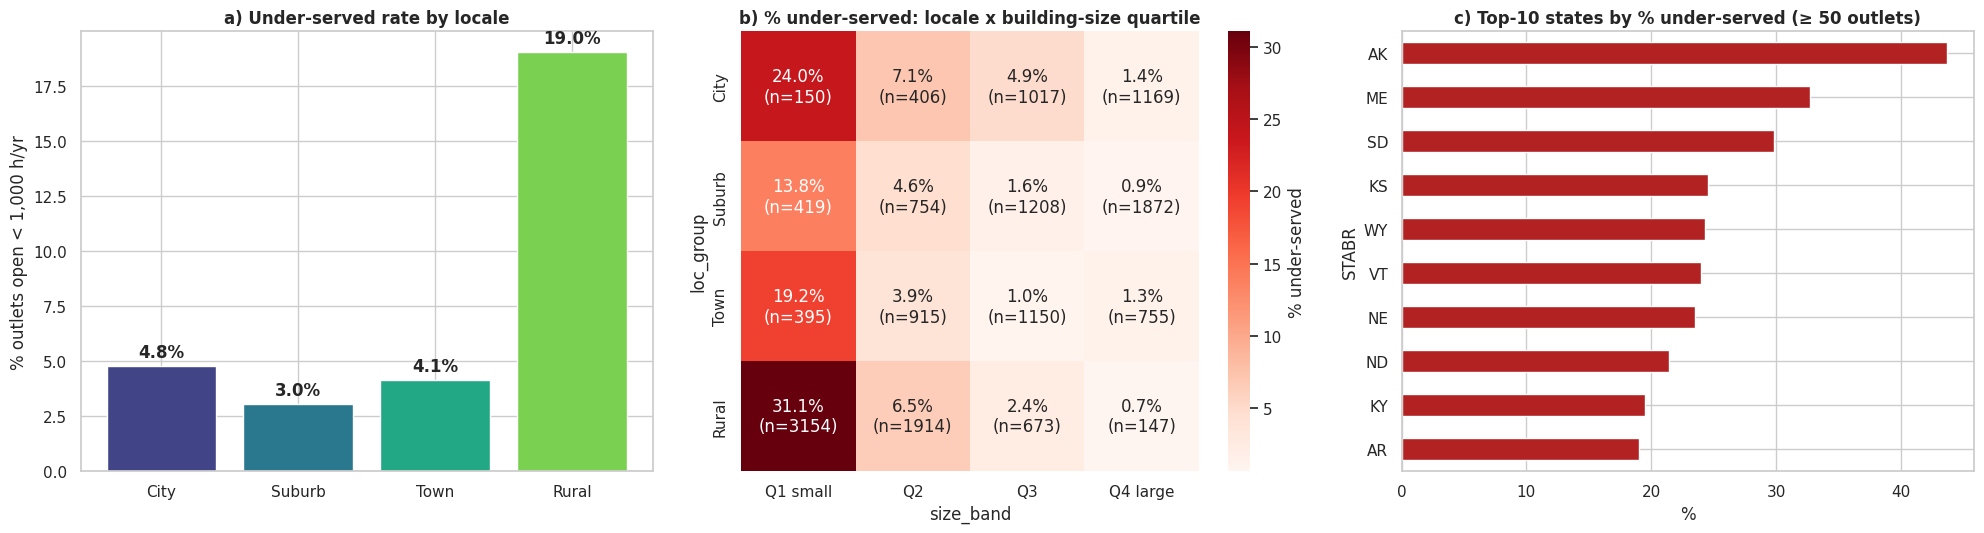

Median state rate = 9.4% | max = 43.7%


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5.5))
# a) rate by locale
ax[0].bar(tab.index.astype(str), tab["rate_%"], color=sns.color_palette("viridis", 4))
for i, v in enumerate(tab["rate_%"]): ax[0].text(i, v + .4, f"{v:.1f}%", ha="center", fontweight="bold")
ax[0].set_ylabel("% outlets open < 1,000 h/yr"); ax[0].set_title("a) Under-served rate by locale")

# b) locale x building-size quartile
ob["size_band"] = pd.qcut(ob.SQ_FEET, 4, labels=["Q1 small", "Q2", "Q3", "Q4 large"])
hm  = ob.pivot_table(index="loc_group", columns="size_band", values="underserved", aggfunc="mean", observed=True) * 100
cnt = ob.pivot_table(index="loc_group", columns="size_band", values="underserved", aggfunc="size", observed=True)
sns.heatmap(hm, annot=hm.round(1).astype(str) + "%\n(n=" + cnt.astype(str) + ")", fmt="", cmap="Reds", ax=ax[1], cbar_kws={"label": "% under-served"})
ax[1].set_title("b) % under-served: locale x building-size quartile")

# c) top states
st_rate = ob.groupby("STABR").agg(n=("HOURS", "size"), pct=("underserved", "mean")); st_rate = st_rate[st_rate.n >= 50]
(st_rate.pct.nlargest(10) * 100).sort_values().plot.barh(ax=ax[2], color="firebrick")
ax[2].set_title("c) Top-10 states by % under-served (≥ 50 outlets)"); ax[2].set_xlabel("%")
plt.tight_layout(); plt.show()
print("Median state rate = %.1f%% | max = %.1f%%" % (st_rate.pct.median() * 100, st_rate.pct.max() * 100))

## 4.1 Insight extraction — from *what* to *why*
| Question | What the data shows | Why the pattern exists | Value |
|---|---|---|---|
| **Who is under-served?** | Rural outlets: **19.0%** open < 1,000 h/yr vs **4.8%** city, **3.0%** suburb, **4.1%** town. Rural = 37% of outlets but **74%** of under-served ones (1,121 of 1,514). | The divide is *rural vs everyone else*, not a smooth gradient – city, suburb and town are close together. | Targets help at one clearly identifiable group instead of spreading it thinly. |
| **Why are they under-served?** | Rural median floor area ≈ **2,800 sq ft** vs ≈ **13,000** in cities. Under-service drops from **14–31%** in the smallest size quartile to **0.7–1.4%** in the largest, in *every* locale (chart b). | Hours depend on **staff and budget**, and building size is a proxy for both: small buildings mean small budgets and few paid staff, so doors open fewer hours. Rural libraries are under-served mainly *because they are small*, not because they are remote. | The lever is **capacity (staffing, shared services)**, not just location or new buildings. |
| **Is it a closure problem?** | Share of outlets open < 52 weeks is similar everywhere (≈ 18–22%). COVID closures cut *weeks*, not daily hours. | The rural gap is in **daily / weekly hours**, not seasonal shutdowns. | Solutions should target *schedules*, not reopening. |
| **Is population the driver?** | Hours correlate ≈ 0.37 with county population but ≈ 0.70 with size; population and size are themselves correlated. | Populous counties build bigger libraries, which then open longer – the effect runs *through* size. | Population alone is a poor guide for deciding where to invest. |
| **Where is it worst?** | Alaska (43.7%), Maine (32.7%), South Dakota (29.9%), Kansas (24.5%), Wyoming (24.3%), Vermont (24.0%) vs a **9.4%** median state. | These are largely rural states (≈ 70–76% rural outlets in AK, ME, SD, KS). Wisconsin and Iowa differ despite similar rurality, pointing to **state funding and policy**. | Shows where state-level programmes would reach the most people. Alaska has only 71 outlets, so its rate is noisy. |

> **Data caveat:** all numbers are associations from one survey year. Hours are only a *proxy* for access (they ignore programmes, digital services and outreach), and 1,000 h/yr is a convention – other thresholds would shift the absolute rates but the rural-vs-other ranking was robust to imputation (9.4% vs 9.9% under-served overall).

## 4.2 Contextualization — real-world domain applications
* **Public services / community development:** libraries are often the only free public space with internet, computers and staff help in small towns. A rural outlet open ≈ 20 h/week or less restricts when residents can use them – especially people who work during the day.
* **Education & workforce:** limited hours reduce access to homework help, job-search support and digital-skills training, so the gap compounds existing rural–urban disparities.
* **Healthcare & social services:** libraries increasingly host telehealth access, benefits applications and public-health information; short opening hours narrow the reach of these services exactly where clinics are also far away.
* **Disaster management:** libraries commonly serve as information hubs, charging points and cooling/warming centres during emergencies. Where they are open only a few hours a week, that resilience role is weaker – so identifying low-hours outlets is also a *preparedness* question.
* **Data governance:** the quality issues found in Phase 1 (hidden negative codes, impossible hours) show how survey design choices can silently distort policy decisions – a lesson relevant to any administrative dataset.

## Limitations
* **Associations, not causes** – the survey has no budget, staffing or demand data, so we cannot say *why* small libraries are small.
* **Hours are a proxy for access** – bookmobiles and digital/outreach services are not captured as building access.
* **County population is a coarse proxy** for each outlet's catchment and repeats across outlets in the same county.
* Outlets in the same library system are not independent, so any significance statements would be optimistic; this notebook therefore relies on **effect sizes and visible patterns** rather than p-values.